## 8. Environment Setup & Data Loading
Setting up the analytics environment and loading the predictive datasets generated during the Day 2 pipeline.

### 8.1 Importing Analytics Libraries

In [1]:
#import core analytics and visualization libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

#suppress warnings for cleaner output
warnings.filterwarnings('ignore')

#set default seaborn styling for analytics visualizations
sns.set_theme(style="whitegrid")

### 8.2 Loading the Processed HR Datasets
We need both the master processed dataset (for deep-dive correlation) and the predictive insights report (for risk categorization and recommendation targeting).

In [2]:
#define the directory path containing day 2 outputs
PROCESSED_DIR = r'D:\OFFICE\Tasks\AI_based_HR_system\data\processed\\'

#load the datasets inside a try-except block to handle missing files gracefully
try:
    #load the comprehensive hr dataset engineered in day 2
    final_hr_df = pd.read_csv(PROCESSED_DIR + 'final_hr_dataset_processed.csv')
    
    #load the predictive insights report generated in day 2
    insights_report_df = pd.read_csv(PROCESSED_DIR + 'hr_predictive_insights_report.csv')
    
    print("successfully loaded processed datasets for day 3 analytics.")
    print(f"final hr dataset shape: {final_hr_df.shape}")
    print(f"insights report shape: {insights_report_df.shape}")
    
except FileNotFoundError as e:
    print(f"error loading files. please ensure the pipeline completed successfully. details: {e}")

successfully loaded processed datasets for day 3 analytics.
final hr dataset shape: (2000, 30)
insights report shape: (2000, 8)


---
## 9. Deep-Dive Analytics & Correlation
Now that our predictive models have scored the workforce, we transition to business intelligence. In this section, we analyze the macroscopic trends across the organization to uncover the root causes of performance and turnover.

### 9.1 Global Correlation Analysis 
Before we make recommendations, we must prove to stakeholders mathematically *how* variables interact. A correlation matrix helps us identify hidden relationships—for example, confirming if high absenteeism strictly correlates with lower KPI scores, or if higher base salaries actually reduce attrition risk.

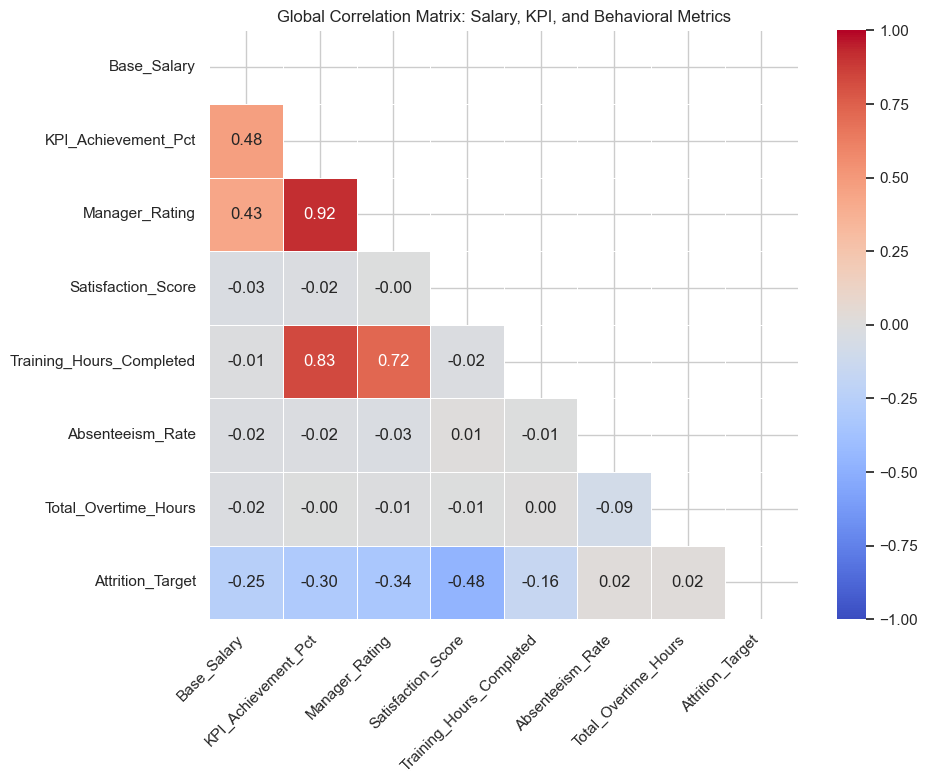

In [4]:
#select the most critical numerical features for a clean, readable correlation matrix
key_features = [
    'Base_Salary', 
    'KPI_Achievement_Pct', 
    'Manager_Rating',
    'Satisfaction_Score', 
    'Training_Hours_Completed',
    'Absenteeism_Rate', 
    'Total_Overtime_Hours', 
    'Attrition_Target'
]

#calculate the pearson correlation matrix
corr_matrix = final_hr_df[key_features].corr()

#set up the matplotlib figure
plt.figure(figsize=(10, 8))

#create a mask to hide the upper triangle for a cleaner visual presentation
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

#plot the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    square=True,
    linewidths=.5
)

plt.title('Global Correlation Matrix: Salary, KPI, and Behavioral Metrics')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 9.2 Department-Wise Analytics
Macro-level correlations are great for general strategy, but resource allocation happens at the department level. Here, we aggregate our predictive metrics to identify which departments are thriving and which are systemic flight risks requiring immediate HR intervention.

--- Department-Wise Analytics Summary ---


,Department,Avg_KPI,Avg_Satisfaction,Avg_Absenteeism,Total_Attrition_Risk,Total_Employees,Attrition_Risk_Pct
1,HR,96.9,2.88,0.011,38,111,34.2
3,Operations,97.7,2.99,0.010,150,518,29.0
4,Sales,99.3,2.99,0.010,111,390,28.5
5,Technology,98.5,3.02,0.009,145,571,25.4
0,Finance,97.8,3.04,0.009,51,207,24.6
2,Marketing,98.7,3.11,0.010,50,203,24.6


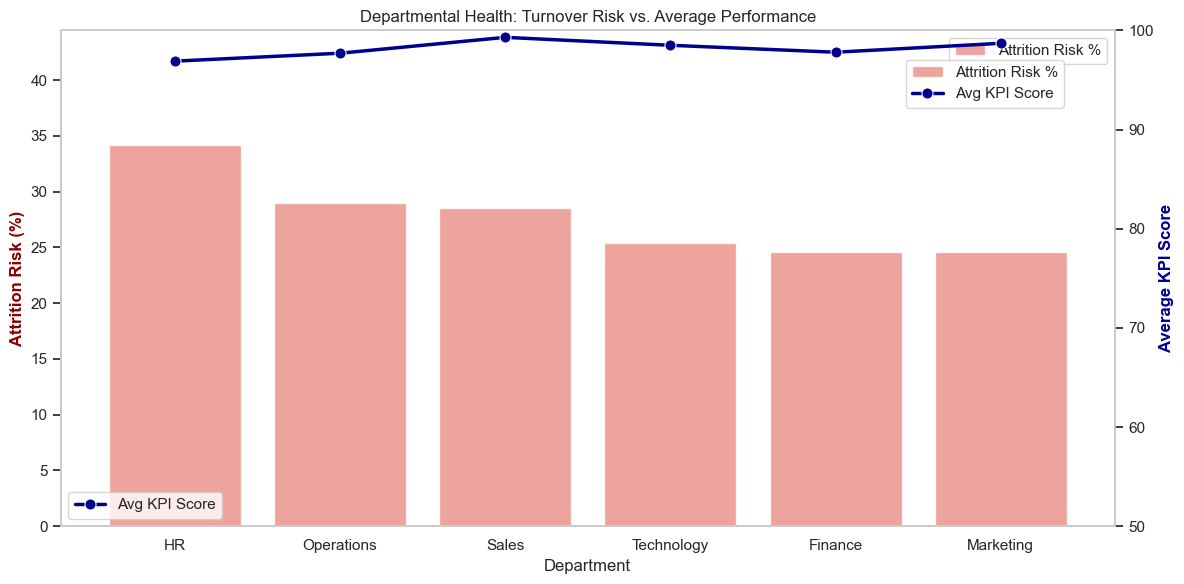

In [5]:
#aggregate key health metrics by department
dept_analytics = final_hr_df.groupby('Department').agg(
    Avg_KPI=('KPI_Achievement_Pct', 'mean'),
    Avg_Satisfaction=('Satisfaction_Score', 'mean'),
    Avg_Absenteeism=('Absenteeism_Rate', 'mean'),
    Total_Attrition_Risk=('Attrition_Target', 'sum'),
    Total_Employees=('Employee_ID', 'count')
).reset_index()

#calculate the explicit attrition risk percentage per department
dept_analytics['Attrition_Risk_Pct'] = (dept_analytics['Total_Attrition_Risk'] / dept_analytics['Total_Employees'] * 100).round(1)

#round continuous variables for clean dashboard reporting
dept_analytics['Avg_KPI'] = dept_analytics['Avg_KPI'].round(1)
dept_analytics['Avg_Satisfaction'] = dept_analytics['Avg_Satisfaction'].round(2)
dept_analytics['Avg_Absenteeism'] = dept_analytics['Avg_Absenteeism'].round(3)

#sort by attrition risk to highlight critical departments first
dept_analytics = dept_analytics.sort_values(by='Attrition_Risk_Pct', ascending=False)

print("--- Department-Wise Analytics Summary ---")
display(dept_analytics)

#visualize departmental health: attrition risk vs performance
fig, ax1 = plt.subplots(figsize=(12, 6))

#bar chart for attrition risk on the primary y-axis
sns.barplot(
    data=dept_analytics, 
    x='Department', 
    y='Attrition_Risk_Pct', 
    ax=ax1, 
    color='salmon', 
    alpha=0.8, 
    label='Attrition Risk %'
)
ax1.set_ylabel('Attrition Risk (%)', color='darkred', fontweight='bold')
ax1.set_ylim(0, max(dept_analytics['Attrition_Risk_Pct']) * 1.3)

#line chart for average kpi on the secondary y-axis
ax2 = ax1.twinx()
sns.lineplot(
    data=dept_analytics, 
    x='Department', 
    y='Avg_KPI', 
    ax=ax2, 
    color='darkblue', 
    marker='o', 
    linewidth=2.5, 
    markersize=8,
    label='Avg KPI Score'
)
ax2.set_ylabel('Average KPI Score', color='darkblue', fontweight='bold')
ax2.set_ylim(50, 100)

plt.title('Departmental Health: Turnover Risk vs. Average Performance')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
ax1.grid(False)
ax2.grid(False)
plt.tight_layout()
plt.show()

---
## 10. Employee Risk Categorization
To make our AI predictions actionable for HR, we must translate raw probabilities and KPI forecasts into a strategic framework. We will adapt the traditional HR "9-Box Grid." Instead of the standard Performance vs. Potential, we will map **Forecasted Performance vs. Flight Risk**, creating clear segments like "High-Risk Top Performer" (requires immediate retention effort) or "Low-Risk Low Performer" (requires training or transition).

### 10.1 Defining the 9-Box Grid / Risk Segments
We establish the mathematical thresholds for what constitutes High, Medium, and Low for both performance and attrition probability.

In [6]:
#define thresholds for performance based on predicted kpi
def categorize_performance(kpi):
    if kpi >= 85:
        return 'High'
    elif kpi >= 70:
        return 'Medium'
    else:
        return 'Low'

#define thresholds for flight risk based on xgboost attrition probability
def categorize_risk(prob):
    if prob >= 0.70:
        return 'High'
    elif prob >= 0.30:
        return 'Medium'
    else:
        return 'Low'

print("risk and performance thresholds successfully defined.")

risk and performance thresholds successfully defined.


### 10.2 Mapping Employees to Risk Categories
We will now apply these thresholds to the `insights_report_df` generated in Day 2, effectively sorting every employee into one of the 9 strategic boxes, and visualize the distribution across the organization.

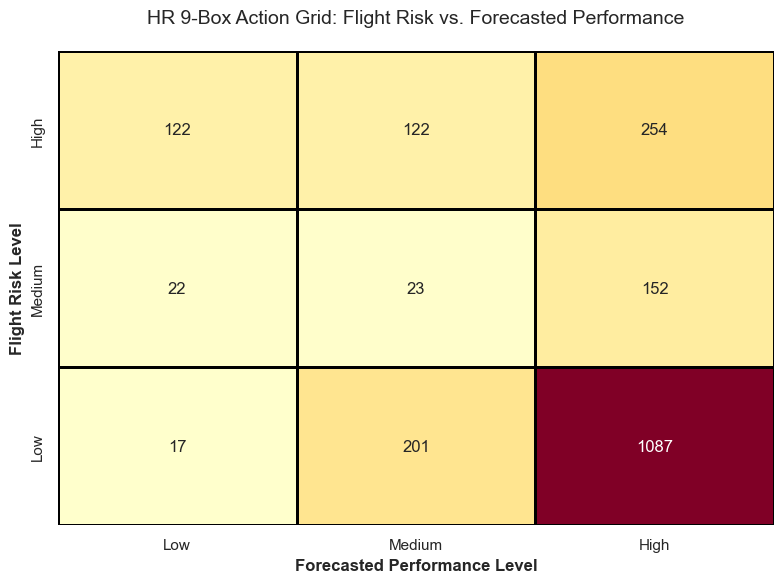

CRITICAL TALENT ALERT: 254 Top Performers are at High Risk of leaving.


In [7]:
#apply categorization functions to our predictive insights dataset
insights_report_df['Performance_Level'] = insights_report_df['Forecasted_KPI_Score'].apply(categorize_performance)
insights_report_df['Flight_Risk_Level'] = insights_report_df['Attrition_Probability'].apply(categorize_risk)

#create the combined 9-box segment label
insights_report_df['Risk_Segment'] = insights_report_df['Flight_Risk_Level'] + " Risk, " + insights_report_df['Performance_Level'] + " Performer"

#generate a frequency matrix for the 9-box grid
nine_box_matrix = pd.crosstab(
    insights_report_df['Flight_Risk_Level'], 
    insights_report_df['Performance_Level']
)

#reorder the rows and columns so 'High' risk is at the top and 'High' performance is on the right
nine_box_matrix = nine_box_matrix.reindex(
    index=['High', 'Medium', 'Low'], 
    columns=['Low', 'Medium', 'High']
)

#visualize the 9-box grid using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    nine_box_matrix, 
    annot=True, 
    fmt='d', 
    cmap='YlOrRd', 
    cbar=False,
    linewidths=2,
    linecolor='black'
)

plt.title('HR 9-Box Action Grid: Flight Risk vs. Forecasted Performance', pad=20, fontsize=14)
plt.xlabel('Forecasted Performance Level', fontweight='bold')
plt.ylabel('Flight Risk Level', fontweight='bold')
plt.tight_layout()
plt.show()

#display the count of our most critical segment: high-risk top performers
critical_talent = insights_report_df[insights_report_df['Risk_Segment'] == 'High Risk, High Performer']
print(f"CRITICAL TALENT ALERT: {len(critical_talent)} Top Performers are at High Risk of leaving.")

---
## 11. AI-Based Recommendation Modules (The Core Engine)
This section implements the prescriptive analytics layer of the system. Using the predictive insights generated by our machine learning models, we interface with the GroqCloud API using a Llama 3 model to transform raw risk scores and metrics into highly personalized, human-readable corporate strategies.

### 11.1 Module A: Retention Strategy Recommender
This module isolates employees flagged as high flight risks. It compiles their key behavioral data points (compa-ratio, satisfaction scores, and overtime hours) and sends a structured prompt to the Groq API to generate targeted, immediate intervention strategies for HR managers.

In [15]:
import os
from groq import Groq
from dotenv import load_dotenv

# Load the .env file from your base directory
load_dotenv()

# Initialize the Groq client 
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

def generate_retention_strategy(employee_row):
    """
    generates a personalized retention strategy for a high-risk employee using the groq cloud api.
    
    parameters:
    employee_row (pd.Series): a single row containing employee features and risk metrics.
    
    returns:
    str: a textual actionable mitigation plan generated by the llm.
    """
    # construct a strict contextual prompt for the generative ai model
    prompt = f"""
    You are an expert HR corporate psychologist and talent retention strategist. 
    Analyze the following employee profile and provide exactly three highly specific, actionable intervention steps to prevent them from resigning.
    Do not use generic advice. Focus heavily on their specific data metrics.

    Employee Metrics:
    - Employee ID: {employee_row['Employee_ID']}
    - Department: {employee_row['Department']}
    - Attrition Probability: {employee_row['Attrition_Probability'] * 100:.1f}%
    - Forecasted KPI Score: {employee_row['Forecasted_KPI_Score']}
    - Satisfaction Score (1-5): {employee_row['Satisfaction_Score']}
    - Work-Life Balance Rating (1-5): {employee_row['Work_Life_Balance']}
    - Compa-Ratio (Salary vs Dept Median): {employee_row['Compa_Ratio']:.2f}
    - Total Overtime Hours worked: {employee_row['Total_Overtime_Hours']:.1f}
    - Attendance Anomaly Status: {employee_row['Attendance_Status']}

    Format the output cleanly as:
    ### Actionable Retention Plan for {employee_row['Employee_ID']}
    1. [Strategy 1]
    2. [Strategy 2]
    3. [Strategy 3]
    """

    try:
        # call the groq cloud api using the llama3 8b model for low latency execution
        chat_completion = client.chat.completions.create(
            messages=[
                {
                    "role": "system",
                    "content": "You generate concise, executive-grade corporate talent strategies. Maintain an academic, professional tone devoid of conversational fillers or introductory pleasantries."
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            model="llama-3.1-8b-instant",
            temperature=0.2,
            max_tokens=400
        )
        return chat_completion.choices[0].message.content
    except Exception as e:
        return f"api generation failed for {employee_row['Employee_ID']}. error context: {str(e)}"

# merge behavioral metrics back into the insights dataframe to provide context for the llm
full_insights_df = insights_report_df.merge(
    final_hr_df[['Employee_ID', 'Satisfaction_Score', 'Work_Life_Balance', 'Compa_Ratio', 'Total_Overtime_Hours']], 
    on='Employee_ID', 
    how='left'
)

# test the retention engine prototype on the top high-risk employee
high_risk_sample = full_insights_df[full_insights_df['Flight_Risk_Level'] == 'High'].iloc[0]
sample_retention_plan = generate_retention_strategy(high_risk_sample)
print(sample_retention_plan)

### Actionable Retention Plan for EMP00950

1. **Realign Compensation Package to Meet Departmental Standards**: Given EMP00950's Compa-Ratio of 0.43, which is significantly below the departmental median, a salary adjustment is necessary to bring their compensation in line with industry standards. A 15% salary increase, totaling $12,000, would be a reasonable target to achieve a Compa-Ratio of 0.65, which is more in line with the departmental median. This adjustment will help address the employee's low satisfaction score and reduce the likelihood of resignation.

2. **Implement Flexible Work Arrangements to Improve Work-Life Balance**: EMP00950's Work-Life Balance Rating of 1 indicates a severe imbalance between work and personal life. To address this, offer flexible work arrangements, such as a compressed workweek (e.g., 4 days x 10 hours) or telecommuting options, to allow the employee to better manage their workload and personal responsibilities. This will help reduce the employee's 

### 11.2 Module B: Training & Upskilling Recommender
This module targets individuals flagged as low or average performers with declining KPI forecasts. By mapping their current performance levels against their completed training hours, the module prompts the AI to recommend specific, tailored technical or behavioral upskilling pathways.

In [16]:
def generate_upskilling_recommendation(employee_row):
    """
    analyzes an employee's skill gaps and performance metrics to generate targeted training track recommendations.
    
    parameters:
    employee_row (pd.Series): a single row containing employee performance data.
    
    returns:
    str: a textual training recommendation plan generated by the llm.
    """
    prompt = f"""
    You are a corporate learning and development (l&d) director. 
    Design a targeted professional development intervention path for an employee underperforming in their core metrics.

    Employee Performance Data:
    - Employee ID: {employee_row['Employee_ID']}
    - Functional Department: {employee_row['Department']}
    - Current Forecasted KPI Score: {employee_row['Forecasted_KPI_Score']}/120
    - Total Training Hours Completed: {employee_row['Training_Hours_Completed']} hours
    - Manager Performance Rating: {employee_row['Manager_Rating']}/5

    Provide a concise, direct recommendation outlining:
    1. The exact technical skill track or course focus they require based on their department.
    2. The target number of structured training hours they must complete to bridge the performance gap.
    """

    try:
        chat_completion = client.chat.completions.create(
            messages=[
                {
                    "role": "system",
                    "content": "You are an executive instructional designer. Provide structural, precise education pathways using formal corporate terminology without any preamble."
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            model="llama-3.1-8b-instant",
            temperature=0.1,
            max_tokens=300
        )
        return chat_completion.choices[0].message.content
    except Exception as e:
        return f"training api generation failed. error context: {str(e)}"

# append the training hours completed from the master dataset to the insights dataset
full_insights_df = full_insights_df.merge(
    final_hr_df[['Employee_ID', 'Training_Hours_Completed', 'Manager_Rating']], 
    on='Employee_ID', 
    how='left'
)

# test the upskilling engine prototype on an underperforming employee
low_perf_sample = full_insights_df[full_insights_df['Performance_Level'] == 'Low'].iloc[0]
sample_training_plan = generate_upskilling_recommendation(low_perf_sample)
print(sample_training_plan)

**Employee Performance Improvement Plan (EPIP) for EMP00950**

**Departmental Analysis and Skill Gap Identification:**

Based on the employee's functional department (Technology), the primary skill gaps contributing to underperformance are:

1. **Cloud Computing Fundamentals**: EMP00950 requires foundational knowledge of cloud infrastructure, migration strategies, and security best practices to enhance their technical expertise.
2. **Agile Methodologies**: As a Technology department employee, EMP00950 must understand Agile principles, Scrum framework, and iterative development methodologies to improve collaboration and project delivery.

**Targeted Training Intervention Path:**

To bridge the performance gap, EMP00950 must complete the following structured training hours:

1. **Cloud Computing Fundamentals**:
	* Course Title: AWS Cloud Practitioner Essentials
	* Course Duration: 12 hours
	* Target Completion Date: 6 weeks from the start of the EPIP
2. **Agile Methodologies**:
	* Course

### 11.3 Module C: Workforce Optimization & Resource Allocation
Moving from individual analytics to macroscopic workforce planning, this module feeds the entire aggregated departmental dataframe (`dept_analytics`) into the Groq API. The engine analyzes workforce under-utilization, operational over-utilization (burnout), and turnover rates to issue prescriptive resource redistribution and hiring recommendations.

In [17]:
def generate_workforce_optimization_insights(dept_dataframe):
    """
    accepts the aggregated departmental analytics dataframe and leverages generative ai to provide resource redistribution strategies.
    
    parameters:
    dept_dataframe (pd.DataFrame): the aggregated department health dataframe from section 9.2.
    
    returns:
    str: a macroscopic organizational workforce report.
    """
    # convert the dataframe data into a clean text string layout for the model to parse
    dataframe_string = dept_dataframe.to_string(index=False)
    
    prompt = f"""
    You are an enterprise workforce planning consultant and chief operations officer. 
    Analyze the following departmental performance and attrition metrics data matrix:

    {dataframe_string}

    Provide a strategic macro workforce allocation brief addressing:
    1. Which department requires immediate headcount expansion or headcount reduction/redistribution based on performance versus turnover risk metrics.
    2. Specific cross-departmental resource allocation strategies to optimize corporate efficiency.
    """

    try:
        chat_completion = client.chat.completions.create(
            messages=[
                {
                    "role": "system",
                    "content": "You generate highly analytical organizational development briefs. Rely strictly on statistical anomalies within the text matrix to justify your strategy."
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            model="llama-3.1-8b-instant",
            temperature=0.2,
            max_tokens=500
        )
        return chat_completion.choices[0].message.content
    except Exception as e:
        return f"workforce optimization generation failed. error context: {str(e)}"

# test the macroscopic workforce planning engine using the dataframe created in section 9.2
macro_workforce_strategy = generate_workforce_optimization_insights(dept_analytics)
print("--- Global Macro Workforce Optimization Brief ---")
print(macro_workforce_strategy)

--- Global Macro Workforce Optimization Brief ---
**Strategic Macro Workforce Allocation Brief**

**Executive Summary:**

Based on the provided departmental performance and attrition metrics data matrix, our analysis reveals significant disparities in turnover risk and performance metrics across departments. This brief outlines a strategic macro workforce allocation plan to address these disparities, focusing on immediate headcount adjustments and cross-departmental resource allocation strategies to optimize corporate efficiency.

**Departmental Analysis:**

1. **High Turnover Risk Departments:**
	* Operations: With a Total_Attrition_Risk of 150 and an Attrition_Risk_Pct of 29.0%, Operations requires immediate attention to mitigate turnover risk. We recommend a headcount expansion of 10-15% to address the high attrition risk.
	* Marketing: With a Total_Attrition_Risk of 50 and an Attrition_Risk_Pct of 24.6%, Marketing also requires attention. We suggest a headcount expansion of 5-10% t

---
## 12. Deliverables & Reports Generation
In this final phase of the analytics pipeline, we export our aggregated findings into standardized reporting formats and construct the modular Python class that will serve as the backend engine for the upcoming interactive dashboard.

### 12.1 Generating & Exporting the Department-Wise Insight Summary
We will export the departmental aggregations as both a CSV for programmatic use and a Markdown file for formal documentation and review by stakeholders.

In [20]:
#define output directory for reporting artifacts
reports_dir = r'D:\OFFICE\Tasks\AI_based_HR_system\reports\\'
os.makedirs(reports_dir, exist_ok=True)

#export the department analytics to csv
dept_analytics.to_csv(reports_dir + 'department_insight_summary.csv', index=False)

#export the department analytics to a formal markdown table
dept_analytics.to_markdown(reports_dir + 'department_insight_summary.md', index=False)

print("department-wise insight summaries successfully generated.")

department-wise insight summaries successfully generated.


### 12.2 Generating & Exporting the Comprehensive Analytics Report
We consolidate the master feature dataset with all predictive insights and categorizations (the 9-box grid segments) into a single, comprehensive reporting artifact.

In [21]:
#export the comprehensive insights dataframe to csv
full_insights_df.to_csv(reports_dir + 'comprehensive_analytics_report.csv', index=False)

print("comprehensive analytics report successfully generated.")

comprehensive analytics report successfully generated.
